# Clasificación de audios
En este notebook vamos a probar varios modelos para clasificar los audios en reales y generados según las características y los audios.

## 1 Imports

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgbm
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve, matthews_corrcoef)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np
import json
from sklearn.pipeline import Pipeline

In [2]:
import warnings
warnings.filterwarnings('ignore')

## 2 Preparar los datos

In [3]:
SPOOF = "Features\\spoof_features.csv"
BONAFIDE = 'Features\\bonafide_features.csv'

RANDOM_STATE = 12
TEST_SPLIT = 0.2

In [4]:
df_spoof = pd.read_csv(SPOOF)
df_bonafide = pd.read_csv(BONAFIDE)

In [5]:
df = pd.concat([df_spoof, df_bonafide], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [6]:
df['pitch'] = df['pitch'].apply(lambda x: np.array(json.loads(x)))
df['f1'] = df['f1'].apply(lambda x: json.loads(x))
df['f2'] = df['f2'].apply(lambda x: json.loads(x))
df['f3'] = df['f3'].apply(lambda x: json.loads(x))
for col in df.columns:
    if 'mfcc' in col and not col.endswith('mean'):
        df[col] = df[col].apply(lambda x: np.array(json.loads(x)))

In [7]:
df = df.drop(['pitch', 'f1', 'f2', 'f3'], axis=1)
mfcc_cols = [c for c in df.columns if c.startswith('mfcc') and not c.endswith('mean')]
df = df.drop(mfcc_cols, axis=1)

In [8]:
df

,filename,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,Dataset\Generado\Español\E_26_G.wav,3.216687,0.051758,0.085643,1254.503350,1326.277329,2563.505569,0.137293,102.351443,6.978547,...,-24.268038,-14.575477,-9.283944,-12.405594,3.906438,-5.953425,-5.590491,-0.694002,4.627871,0
1,Dataset\Generado\Español\E_48_G.wav,2.206625,0.050090,0.114555,1361.571234,1286.077576,2651.041667,0.194745,204.345071,33.738921,...,-16.042852,-5.291547,-8.852230,-12.420032,-7.720528,1.628054,-6.962458,0.200115,3.936875,0
2,Dataset\Natural\Español\E_49_N.wav,3.656000,0.059918,0.136553,1765.967990,1586.161845,3349.796196,0.018546,225.686035,42.079431,...,-17.003986,-5.797369,-16.223082,-9.647523,-6.975890,-2.169085,-6.030098,-0.352658,7.398267,1
3,Dataset\Generado\Español\E_23_G.wav,2.740687,0.052334,0.070074,1044.101842,1137.657301,2086.845930,0.155904,103.726181,17.271786,...,-21.837030,-13.952543,-5.273086,-15.985622,4.532742,-3.402674,-2.512440,-0.610936,3.189704,0
4,Dataset\Natural\Español\E_27_N.wav,2.824063,0.060682,0.099423,1306.290869,1427.197259,2584.708567,0.017563,99.070182,13.325032,...,-36.884580,-17.921293,-10.599140,-3.910789,4.797422,-3.956316,-4.125283,-0.689673,5.315204,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Dataset\Generado\Español\E_13_G.wav,6.281750,0.063773,0.081907,1163.603803,1124.931612,2250.674175,0.076228,121.485683,16.773291,...,-2.402092,-17.969810,-9.149986,-11.105045,-9.460912,-2.077079,-2.921755,-0.963130,3.135151,0
96,Dataset\Generado\Español\E_12_G.wav,3.309563,0.053563,0.090186,1164.858297,1163.522182,2263.146034,0.136308,124.699746,18.706685,...,-3.416033,-14.082165,-9.485531,-9.562201,-7.460647,-0.784725,-3.263623,-0.955104,4.206410,0
97,Dataset\Generado\Español\E_16_G.wav,3.042562,0.048594,0.066966,1047.294232,1053.587620,2068.929036,0.157650,111.482995,23.065551,...,-1.164710,-14.021972,-6.244248,-1.665420,-4.780271,-0.736931,0.065389,-1.620632,9.519138,0
98,Dataset\Generado\Español\E_35_G.wav,3.774000,0.058605,0.147068,1636.921798,1330.756820,2864.870233,0.130687,196.658212,28.452153,...,-9.550146,-7.320043,-12.479050,-10.272341,-0.991668,3.214933,-4.203745,0.296406,4.571232,0


In [9]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
def evaluacion_modelo(model_name: str, y_true, y_pred, y_pred_proba, 
                      save_figures=False, show_plots=False):
    """
    Evalúa un modelo de clasificación con métricas completas y visualizaciones.
    
    Parameters:
    -----------
    model_name : str
        Nombre del modelo para los títulos
    y_true : array
        Etiquetas reales
    y_pred : array
        Predicciones del modelo
    y_pred_proba : array
        Probabilidades predichas (para ROC)
    save_figures : bool
        Guardar figuras como PNG
    show_plots : bool
        Mostrar gráficos interactivamente
    """
    
    print(f"\n{'='*60}")
    print(f" EVALUACIÓN: {model_name}")
    print(f"{'='*60}")
    
    # 1. MÉTRICAS PRINCIPALES
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    print("\nMÉTRICAS PRINCIPALES:")
    print(f"   • Accuracy:  {accuracy:.4f}  (Porcentaje total de aciertos)")
    print(f"   • Precision: {precision:.4f}  (De los que dije IA, ¿cuántos eran?)")
    print(f"   • Recall:    {recall:.4f}    (De los IA, ¿cuántos detecté?)")
    print(f"   • F1-Score:  {f1:.4f}  (Balance precision-recall)")
    print(f"   • AUC-ROC:   {auc:.4f}  (Capacidad discriminativa)")
    print(f"   • MCC:       {mcc:.4f}  (Coeficiente de correlación de Matthews)")
    
    # 2. CLASSIFICATION REPORT DETALLADO
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, 
                              target_names=['Real (0)', 'IA (1)'],
                              digits=4))
    
    # 3. MATRIZ DE CONFUSIÓN
    cm = confusion_matrix(y_true, y_pred)
    
    if show_plots or save_figures:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Matriz de confusión absoluta
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Real', 'IA'],
                   yticklabels=['Real', 'IA'],
                   ax=axes[0])
        axes[0].set_title(f'Matriz de Confusión - {model_name}\n(Valores absolutos)', 
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Predicho', fontsize=11)
        axes[0].set_ylabel('Real', fontsize=11)
        
        # Matriz de confusión normalizada (porcentajes)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                   xticklabels=['Real', 'IA'],
                   yticklabels=['Real', 'IA'],
                   ax=axes[1])
        axes[1].set_title(f'Matriz de Confusión - {model_name}\n(Valores normalizados)', 
                         fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Predicho', fontsize=11)
        axes[1].set_ylabel('Real', fontsize=11)
        
        plt.tight_layout()
        
        if save_figures:
            filename = f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"\nMatriz guardada como: {filename}")
        
        if show_plots:
            plt.show()
        else:
            plt.close()
    
    # 4. CURVA ROC
    if show_plots or save_figures:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random Classifier (AUC = 0.5)')
        
        # Punto óptimo (Youden's index)
        youden_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[youden_idx]
        plt.plot(fpr[youden_idx], tpr[youden_idx], 'ro', markersize=8,
                label=f'Óptimo threshold = {optimal_threshold:.3f}')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)', fontsize=12)
        plt.ylabel('True Positive Rate (TPR)', fontsize=12)
        plt.title(f'Curva ROC - {model_name}', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right", fontsize=10)
        plt.grid(True, alpha=0.3)
        
        if save_figures:
            filename = f'roc_curve_{model_name.lower().replace(" ", "_")}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Curva ROC guardada como: {filename}")
        
        if show_plots:
            plt.show()
        else:
            plt.close()
    
    # 5. RESUMEN DE ERRORES
    tn, fp, fn, tp = cm.ravel()
    print("\nANÁLISIS DE ERRORES:")
    print(f"   • Verdaderos Negativos (Reales bien clasificados): {tn}")
    print(f"   • Verdaderos Positivos (IA bien clasificados): {tp}")
    print(f"   • Falsos Positivos (Reales clasificados como IA): {fp}")
    print(f"   • Falsos Negativos (IA clasificados como Reales): {fn}")
    print(f"   • Error tipo I (Falsos Positivos): {fp/(fp+tn):.2%}")
    print(f"   • Error tipo II (Falsos Negativos): {fn/(fn+tp):.2%}")
    
    print(f"\n{'='*60}")
    
    # Devolvemos métricas por si se quieren usar después
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'mcc': mcc,
        'confusion_matrix': cm
    }

In [13]:
def evauluacion(model_name: str, test, pred, pred_proba):
    print(f"=== Evaluación {model_name} ===")
    accuracy = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, pred_proba)
    f1 = f1_score(y_test, pred)
    mcc = matthews_corrcoef(y_test, pred)
    
    print("\nMétricas Principales:")
    print(f"  • Accuracy:  {accuracy:.4f}")
    print(f"  • AUC-ROC:   {auc:.4f}")
    print(f"  • F1-Score:  {f1:.4f}")
    print(f"  • MCC:       {mcc:.4f}")
    
    print("\nClassification report:")
    print(classification_report(test, pred))    

## Random Forest

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

In [19]:
evauluacion("Random Forest", y_test, y_pred_rf, y_pred_proba_rf[:, 1])

=== Evaluación Random Forest ===

Métricas Principales:
  • Accuracy:  1.0000
  • AUC-ROC:   1.0000
  • F1-Score:  1.0000
  • MCC:       1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



# RF2

In [14]:
rf_base_model = RandomForestClassifier(
    n_estimators=100,           # Número de árboles
    max_depth=10,                # Profundidad máxima
    min_samples_split=5,         # Mínimo muestras para dividir
    min_samples_leaf=2,          # Mínimo muestras en hoja
    max_features='sqrt',         # Características por división
    random_state=RANDOM_STATE,
    n_jobs=-1,                   # Usar todos los cores
    class_weight='balanced'      # Ajuste para clases desbalanceadas
)

rf_base_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_baseline_rf = rf_base_model.predict(X_test)
y_pred_proba_baseline_rf = rf_base_model.predict_proba(X_test)[:, 1]

In [ ]:
baseline_metrics = evaluacion_modelo(
    "Random Forest - Baseline", 
    y_test, 
    y_pred_baseline_rf, 
    y_pred_proba_baseline_rf
)


 EVALUACIÓN: Random Forest - Baseline

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije IA, ¿cuántos eran?)
   • Recall:    1.0000    (De los IA, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)     1.0000    1.0000    1.0000        10
      IA (1)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 10
   • Falsos Positivos (Reales clasificados como IA): 0
   • Falsos Negativos (IA clasificados como Reales): 0
   • 

In [17]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [18]:
# Evaluamos con diferentes métricas
cv_scores_accuracy = cross_val_score(rf_base_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_f1 = cross_val_score(rf_base_model, X_train, y_train, cv=cv, scoring='f1')
cv_scores_auc = cross_val_score(rf_base_model, X_train, y_train, cv=cv, scoring='roc_auc')

In [19]:
print("\nResultados Validación Cruzada (5 folds):")
print(f"   • Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std()*2:.4f})")
print(f"   • F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
print(f"   • AUC-ROC:  {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std()*2:.4f})")


Resultados Validación Cruzada (5 folds):
   • Accuracy: 1.0000 (+/- 0.0000)
   • F1-Score: 1.0000 (+/- 0.0000)
   • AUC-ROC:  1.0000 (+/- 0.0000)


In [ ]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [ ]:
# Grid Search con validación cruzada
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    rf_param_grid,
    cv=cv,
    scoring='f1',           # Optimizamos F1-score (balance precision/recall)
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=12)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [ ]:
rf_optimized_model = rf_grid_search.best_estimator_

In [ ]:
y_pred_optimized_rf = rf_optimized_model.predict(X_test)
y_pred_proba_optimized_rf = rf_optimized_model.predict_proba(X_test)[:, 1]

In [ ]:
rf_optimized_metrics = evaluacion_modelo(
    "Random Forest - Optimizado", 
    y_test, 
    y_pred_optimized_rf, 
    y_pred_proba_optimized_rf
)


 EVALUACIÓN: Random Forest - Optimizado

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije IA, ¿cuántos eran?)
   • Recall:    1.0000    (De los IA, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)     1.0000    1.0000    1.0000        10
      IA (1)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 10
   • Falsos Positivos (Reales clasificados como IA): 0
   • Falsos Negativos (IA clasificados como Reales): 0
   

## Support Vector Machine 

In [20]:
svm_model = SVC(
    kernel='rbf',       # Kernel radial, funciona bien en problemas no lineales
    C=1.0,              # Parámetro de regularización
    probability=True,   # Para obtener probabilidades luego
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

In [22]:
evauluacion("Support Vector Machine", y_test, y_pred_svm, y_pred_proba_svm[:, 1])

=== Evaluación Support Vector Machine ===

Métricas Principales:
  • Accuracy:  1.0000
  • AUC-ROC:   1.0000
  • F1-Score:  1.0000
  • MCC:       1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## SVM 2

#### kernel lineal

In [ ]:
# SVM con kernel lineal (modelo simple, pocos parámetros)
svm_linear = SVC(
    kernel='linear',           # Frontera de decisión lineal
    C=1.0,                     # Parámetro de regularización
    probability=True,           # Para obtener probabilidades (necesario para AUC-ROC)
    random_state=RANDOM_STATE,
    class_weight='balanced'    # Compensación de clases desbalanceadas
)

svm_linear.fit(X_train_scaled, y_train)

In [ ]:
# Predicciones
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluación
linear_metrics = evaluacion_modelo(
    "SVM - Lineal", 
    y_test, 
    y_pred_linear, 
    y_pred_proba_linear,
    save_figures=True
)

#### kernel no lineal

In [ ]:
# SVM con kernel RBF (Radial Basis Function) - Captura no linealidades
svm_rbf = SVC(
    kernel='rbf',              # Kernel no lineal
    C=1.0,                     # Regularización
    gamma='scale',              # Coeficiente del kernel ('scale' = 1/(n_features * X.var()))
    probability=True,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

svm_rbf.fit(X_train_scaled, y_train)

In [ ]:
# Predicciones
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluación
rbf_metrics = evaluacion_modelo(
    "SVM - RBF", 
    y_test, 
    y_pred_rbf, 
    y_pred_proba_rbf,
    save_figures=True
)

#### k-fold para cv

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Creamos un pipeline con escalado y SVM para validación cruzada


svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalado dentro del pipeline
    ('svm', SVC(kernel='rbf', probability=True, 
                random_state=RANDOM_STATE, class_weight='balanced'))
])

In [ ]:
# Validación cruzada con el pipeline
cv_scores_accuracy = cross_val_score(svm_pipeline, X_train, y_train, 
                                     cv=cv, scoring='accuracy')
cv_scores_f1 = cross_val_score(svm_pipeline, X_train, y_train, 
                               cv=cv, scoring='f1')
cv_scores_auc = cross_val_score(svm_pipeline, X_train, y_train, 
                                cv=cv, scoring='roc_auc')

In [ ]:
print("\nResultados Validación Cruzada SVM RBF (5 folds):")
print(f"   • Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std()*2:.4f})")
print(f"   • F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
print(f"   • AUC-ROC:  {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std()*2:.4f})")

#### grid search

In [ ]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],           # Regularización (logarítmico)
    'svm__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],  # Influencia del kernel
    'svm__kernel': ['rbf']                   # Nos centramos en RBF
}

In [ ]:
# Pipeline con escalado incluido
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE, 
                class_weight='balanced'))
])

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

In [ ]:
# Modelo optimizado
svm_optimized = grid_search.best_estimator_

In [ ]:
# Predicciones con modelo optimizado
y_pred_proba_optimized = svm_optimized.predict_proba(X_test)[:, 1]
y_pred_optimized = svm_optimized.predict(X_test)

In [ ]:
# Evaluación
optimized_metrics = evaluacion_modelo(
    "SVM - Optimizado (RBF)", 
    y_test, 
    y_pred_optimized, 
    y_pred_proba_optimized,
    save_figures=True
)

In [ ]:
# Obtenemos el modelo del pipeline
svm_model = svm_optimized.named_steps['svm']
n_support_vectors = svm_model.n_support_
support_vectors_count = sum(n_support_vectors)

print(f"Total de vectores de soporte: {support_vectors_count}")
print(f"Porcentaje del dataset: {support_vectors_count/len(X_train)*100:.2f}%")
print(f"Vectores clase Real (0): {n_support_vectors[0]}")
print(f"Vectores clase IA (1): {n_support_vectors[1]}")

## LightGBM

In [14]:
# 1. Crear datasets de LightGBM (formato optimizado)
train_data = lgbm.Dataset(X_train, label=y_train)
test_data = lgbm.Dataset(X_test, label=y_test, reference=train_data)

# 2. Configurar parámetros del modelo
params = {
    'objective': 'binary',              # Clasificación binaria
    'metric': 'auc',                     # Métrica de evaluación
    'boosting_type': 'gbdt',              # Gradient Boosting Decision Tree
    'num_leaves': 31,                     # Número máximo de hojas
    'learning_rate': 0.05,                # Tasa de aprendizaje
    'feature_fraction': 0.9,              # Fracción de features para cada árbol
    'bagging_fraction': 0.8,               # Fracción de datos para bagging
    'bagging_freq': 5,                     # Frecuencia de bagging
    'verbose': 0,                          # Silencioso
    'random_state': RANDOM_STATE,
    'force_row_wise': True,                # Para mejor rendimiento
    'min_child_samples': 20                 # Mínimo muestras por hoja
}

In [15]:
# 3. Entrenar el modelo
lgbm_model = lgbm.train(
    params,
    train_data,
    valid_sets=[test_data],      # Para monitorear sobreajuste
    num_boost_round=1000,         # Número máximo de iteraciones
    callbacks=[lgbm.early_stopping(50), lgbm.log_evaluation(100)]  # Early stopping
)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [16]:
y_pred_proba_lgbm = lgbm_model.predict(X_test)  # Probabilidades
y_pred_lgbm = (y_pred_proba_lgbm >= 0.5).astype(int)  # Clases

In [17]:
evauluacion("LightGBM", y_test, y_pred_lgbm, y_pred_proba_lgbm)

=== Evaluación LightGBM ===

Métricas Principales:
  • Accuracy:  1.0000
  • AUC-ROC:   1.0000
  • F1-Score:  1.0000
  • MCC:       1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



# LGBM 2

In [18]:
train_data_lgbm = lgbm.Dataset(X_train, label=y_train)
test_data_lgbm = lgbm.Dataset(X_test, label=y_test, reference=train_data)

In [19]:
lgbm_base_params = {
    'objective': 'binary',              # Clasificación binaria
    'metric': 'binary_logloss',          # Métrica de evaluación
    'boosting_type': 'gbdt',              # Gradient Boosting Decision Tree
    'num_leaves': 31,                     # Número máximo de hojas (controla complejidad)
    'learning_rate': 0.05,                 # Tasa de aprendizaje (eta)
    'feature_fraction': 0.9,               # Fracción de características por iteración
    'bagging_fraction': 0.8,               # Fracción de datos por iteración
    'bagging_freq': 5,                      # Frecuencia de bagging
    'verbose': 0,                           # Modo silencioso
    'random_state': RANDOM_STATE,
    'is_unbalance': True,                    # Compensación automática de clases desbalanceadas
    'num_threads': -1                        # Usar todos los cores
}

In [20]:
lgbm_base_model = lgbm.train(
    lgbm_base_params,
    train_data,
    valid_sets=[test_data],      # Evaluación en validación
    num_boost_round=1000,         # Número máximo de iteraciones
    callbacks=[
        lgbm.early_stopping(50),   # Early stopping si no mejora en 50 rondas
        lgbm.log_evaluation(100)    # Log cada 100 iteraciones
    ]
)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [21]:
y_pred_proba_base_lgbm = lgbm_base_model.predict(X_test)
y_pred_base_lgbm = (y_pred_proba_base_lgbm >= 0.5).astype(int)

In [22]:
svm_base_metrics = evaluacion_modelo(
    "LightGBM - Baseline", 
    y_test, 
    y_pred_base_lgbm, 
    y_pred_proba_base_lgbm,
    save_figures=True
)


 EVALUACIÓN: LightGBM - Baseline

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije IA, ¿cuántos eran?)
   • Recall:    1.0000    (De los IA, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)     1.0000    1.0000    1.0000        10
      IA (1)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz guardada como: confusion_matrix_lightgbm_-_baseline.png
Curva ROC guardada como: roc_curve_lightgbm_-_baseline.png

ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasificados): 

#### k-fold para cv

In [23]:
# Para validación cruzada con LightGBM usamos la interfaz scikit-learn
lgbm_sklearn = lgbm.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=RANDOM_STATE,
    is_unbalance=True,
    n_jobs=-1,
    verbose=-1
)

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_accuracy = cross_val_score(lgbm_sklearn, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_f1 = cross_val_score(lgbm_sklearn, X_train, y_train, cv=cv, scoring='f1')
cv_scores_auc = cross_val_score(lgbm_sklearn, X_train, y_train, cv=cv, scoring='roc_auc')

In [25]:
print("\nResultados Validación Cruzada (5 folds):")
print(f"   • Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std()*2:.4f})")
print(f"   • F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
print(f"   • AUC-ROC:  {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std()*2:.4f})")


Resultados Validación Cruzada (5 folds):
   • Accuracy: 0.9875 (+/- 0.0500)
   • F1-Score: 0.9882 (+/- 0.0471)
   • AUC-ROC:  1.0000 (+/- 0.0000)


In [26]:
param_grid = {
    'num_leaves': [15, 31, 63],           # Controla complejidad del modelo
    'learning_rate': [0.01, 0.05, 0.1],    # Tasa de aprendizaje
    'n_estimators': [100, 200, 300],       # Número de iteraciones
    'min_child_samples': [20, 50, 100],     # Mínimo muestras por hoja
    'subsample': [0.6, 0.8, 1.0],           # Fracción de muestras (bagging)
    'colsample_bytree': [0.6, 0.8, 1.0],    # Fracción de características
    'reg_alpha': [0, 0.1, 0.5],             # Regularización L1
    'reg_lambda': [0, 0.1, 0.5]             # Regularización L2
}

In [27]:
# Grid Search con validación cruzada
lgbm_classifier = lgbm.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    random_state=RANDOM_STATE,
    is_unbalance=True,
    n_jobs=-1,
    verbose=-1
)

In [28]:
grid_search = GridSearchCV(
    lgbm_classifier,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6561 candidates, totalling 32805 fits


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_grid,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'min_child_samples': [20, 50, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,boosting_type,'gbdt'


In [29]:
# Modelo optimizado
lgbm_optimized = grid_search.best_estimator_

In [30]:
y_pred_proba_optimized_lgbm = lgbm_optimized.predict_proba(X_test)[:, 1]
y_pred_optimized_lgbm = lgbm_optimized.predict(X_test)

In [31]:
optimized_metrics = evaluacion_modelo(
    "LightGBM - Optimizado", 
    y_test, 
    y_pred_optimized_lgbm, 
    y_pred_proba_optimized_lgbm,
    save_figures=True
)


 EVALUACIÓN: LightGBM - Optimizado

MÉTRICAS PRINCIPALES:
   • Accuracy:  1.0000  (Porcentaje total de aciertos)
   • Precision: 1.0000  (De los que dije IA, ¿cuántos eran?)
   • Recall:    1.0000    (De los IA, ¿cuántos detecté?)
   • F1-Score:  1.0000  (Balance precision-recall)
   • AUC-ROC:   1.0000  (Capacidad discriminativa)
   • MCC:       1.0000  (Coeficiente de correlación de Matthews)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)     1.0000    1.0000    1.0000        10
      IA (1)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz guardada como: confusion_matrix_lightgbm_-_optimizado.png
Curva ROC guardada como: roc_curve_lightgbm_-_optimizado.png

ANÁLISIS DE ERRORES:
   • Verdaderos Negativos (Reales bien clasificados): 10
   • Verdaderos Positivos (IA bien clasifica

In [10]:
import shap
import matplotlib.pyplot as plt
#from alibi.explainers import ALE, plot_ale
from lime.lime_tabular import LimeTabularExplainer
import dice_ml

from IPython.core.display import HTML
import re

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
y_test = y_test.tolist()

In [17]:
y_test

[0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1]

In [18]:
type(y_pred_rf)

numpy.ndarray

In [19]:
print(f'Valor real del audio: {y_test[0]}')
print(f'Valor predicho del audio: {y_pred_rf[0]}')

Valor real del audio: 0
Valor predicho del audio: 0


In [12]:
def show(model, i, shap_values):
    for j in range(i):
        model(shap_values[j])

In [24]:
def explica_shap(X_train, X_test, n_show, local):
    # Primero entrenamos el modelo
    modelo = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        random_state=RANDOM_STATE
    )
    modelo.fit(X_train, y_train)
    
    # Segundo generamos explicaciones
    explainer = shap.Explainer(modelo.predict, X_train)
    shap_values = explainer(X_test)
    
    # Tercero mostramos los valores shap dependiendo de si es explicación local o global
    if local:
        show(model=shap.plots.waterfall, i=n_show, shap_values=shap_values)
    else:
        shap.summary_plot(shap_values, X_test)
        plt.show()
    
    # Por último devolvemos y_pred por si evaluamos el modelo
    return modelo.predict(X_test)

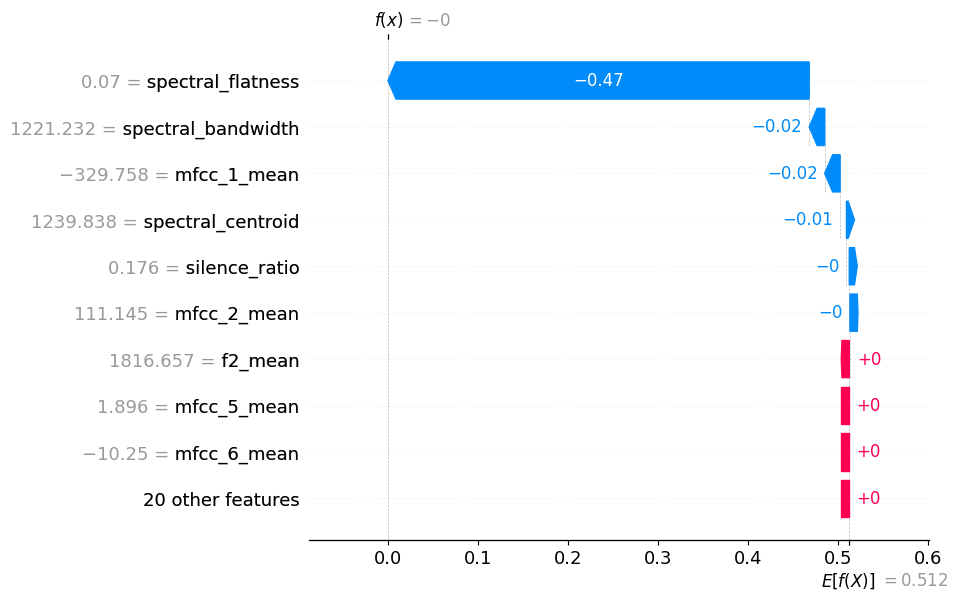

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1],
      dtype=int64)

In [ ]:
explica_shap(X_train=X_train, X_test=X_test, n_show=1, local=True)

C:\Users\Jorge\AppData\Local\Temp\ipykernel_105496\2912171205.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


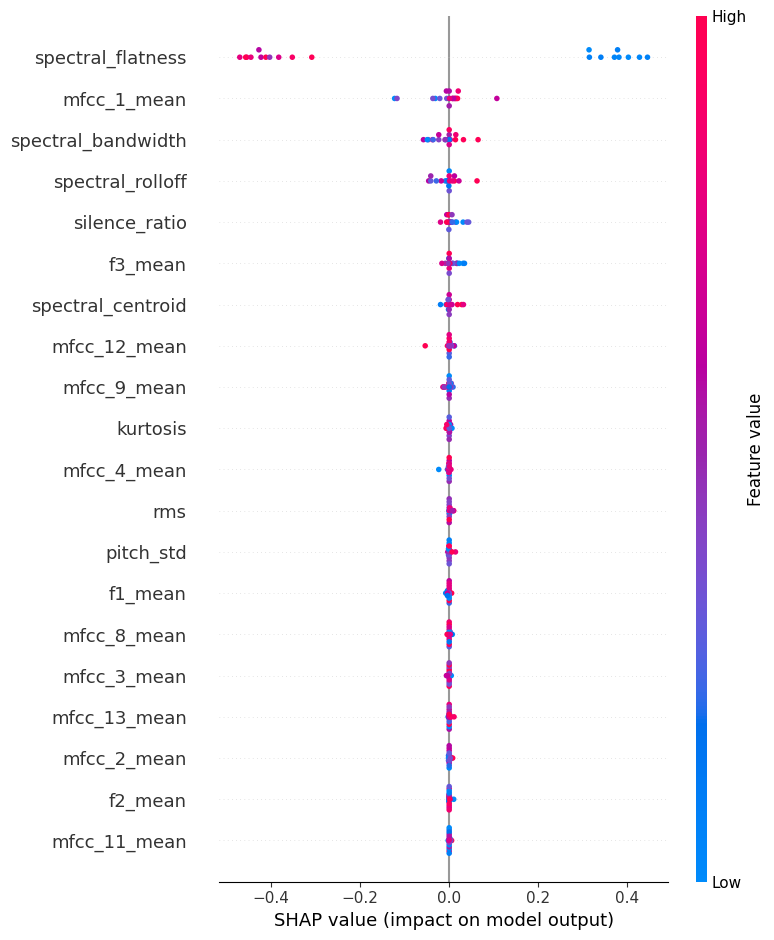

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1],
      dtype=int64)

In [25]:
explica_shap(X_train=X_train, X_test=X_test, n_show=0, local=False)

In [ ]:
def drop_features_explica_shap(X_train, X_test, feats, n_show, evalua_modelo = False, local = True):
    # Primero creamos los nuevos conjuntos de train y test
    X_train_new = X_train.drop(feats, axis=1, inplace=False)
    X_test_new = X_test.drop(feats, axis=1, inplace=False)
    
    # Segundo generamos las explicaciones como antes
    y_pred = explica_shap(X_train=X_train_new, X_test=X_test_new, n_show=n_show, local=local)
    
    # Por último evaluamos el modelo
    if evalua_modelo: evauluacion(model_name='Random Forest', test=y_test, pred=y_pred)

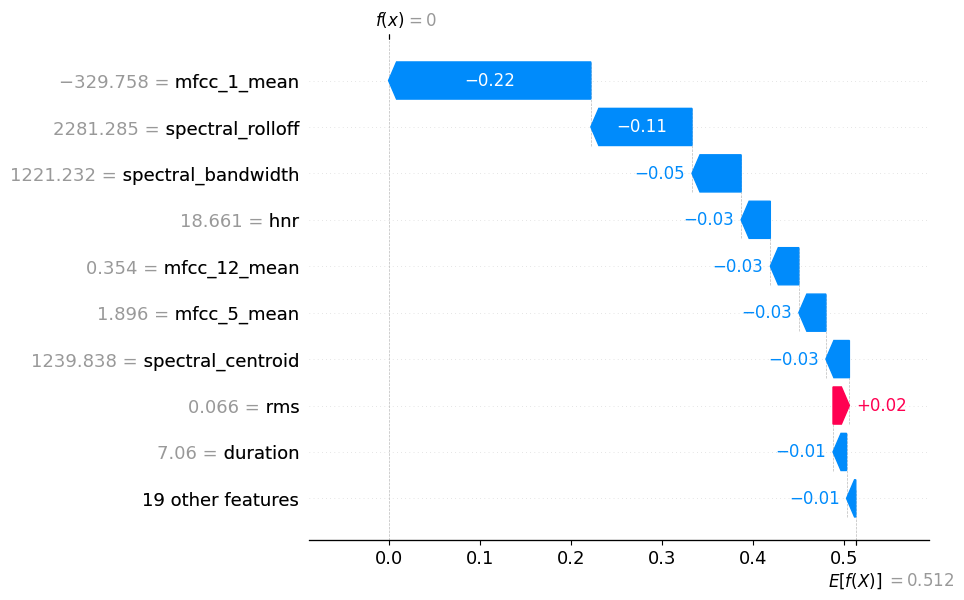

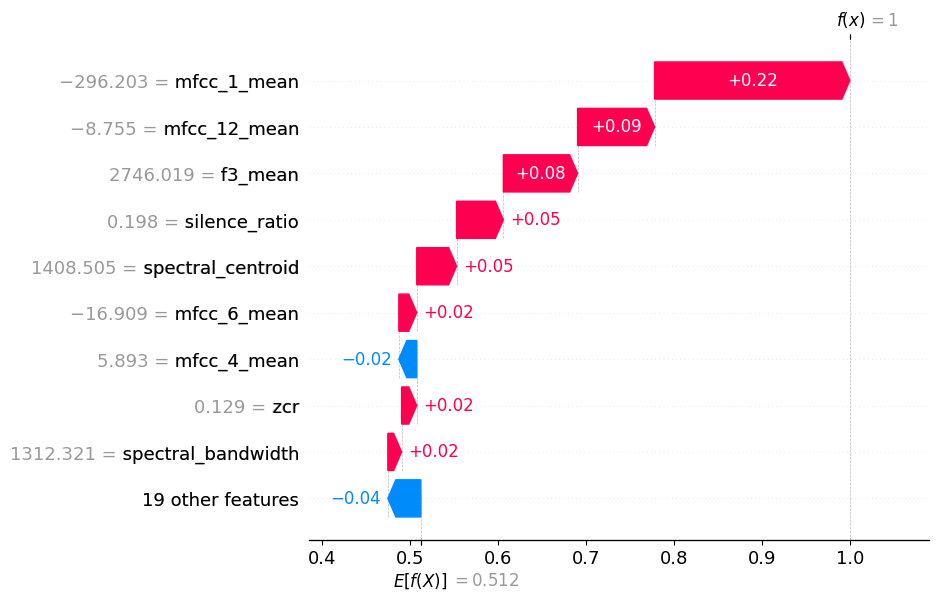

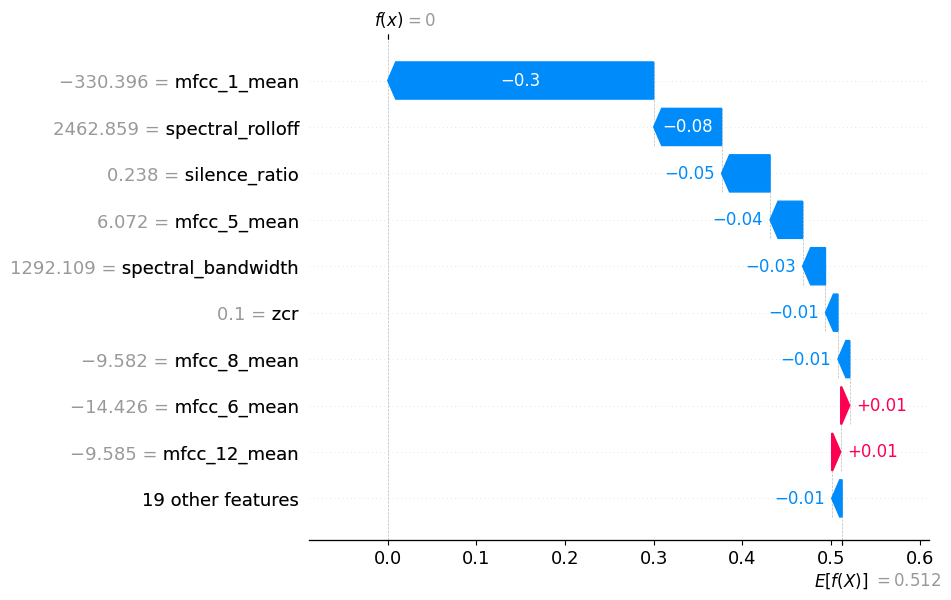

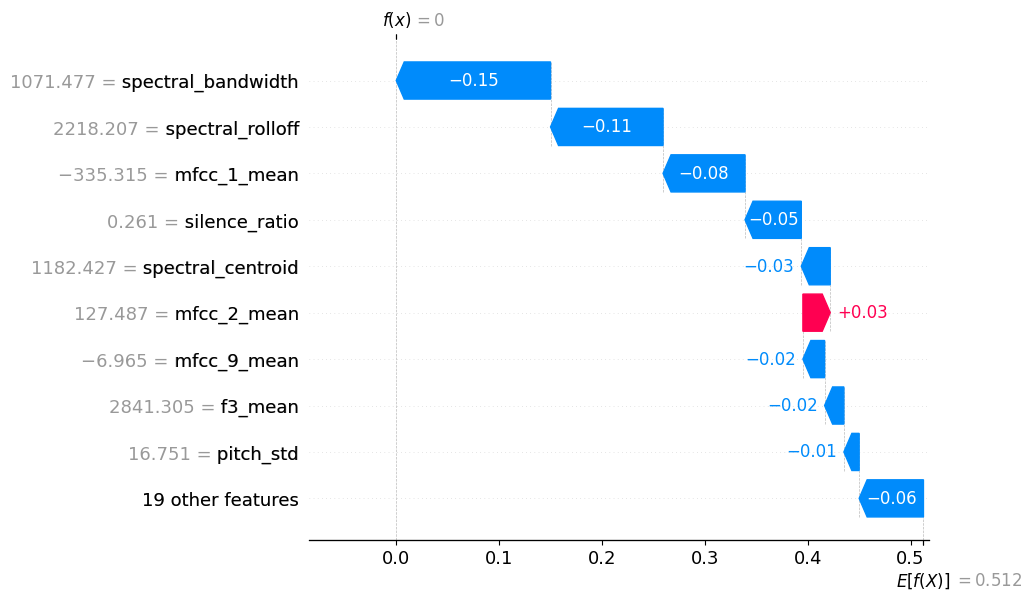

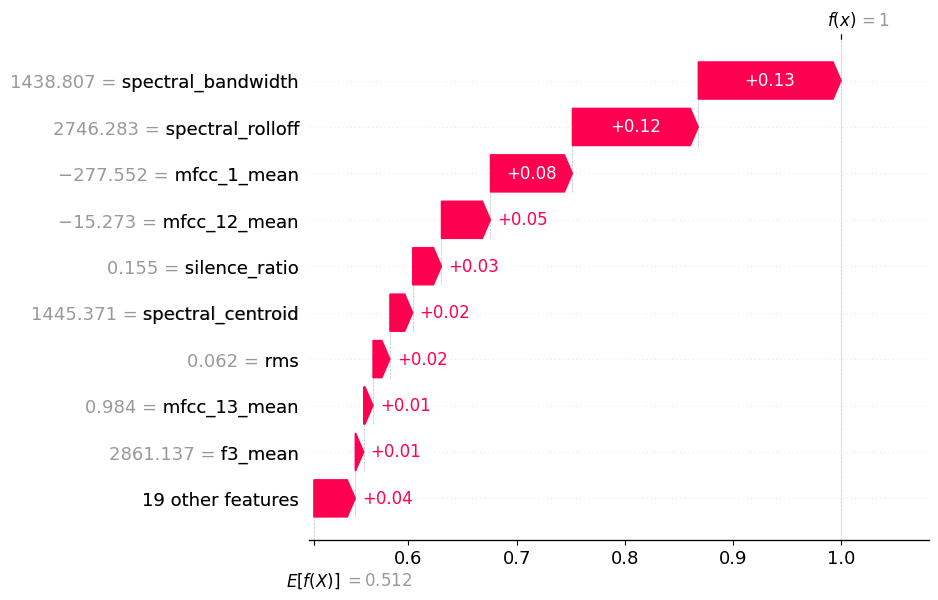

=== Evaluación Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95         9

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
drop_features_explica_shap(X_train=X_train, X_test=X_test, feats='spectral_flatness', n_show=5, evalua_modelo=True)

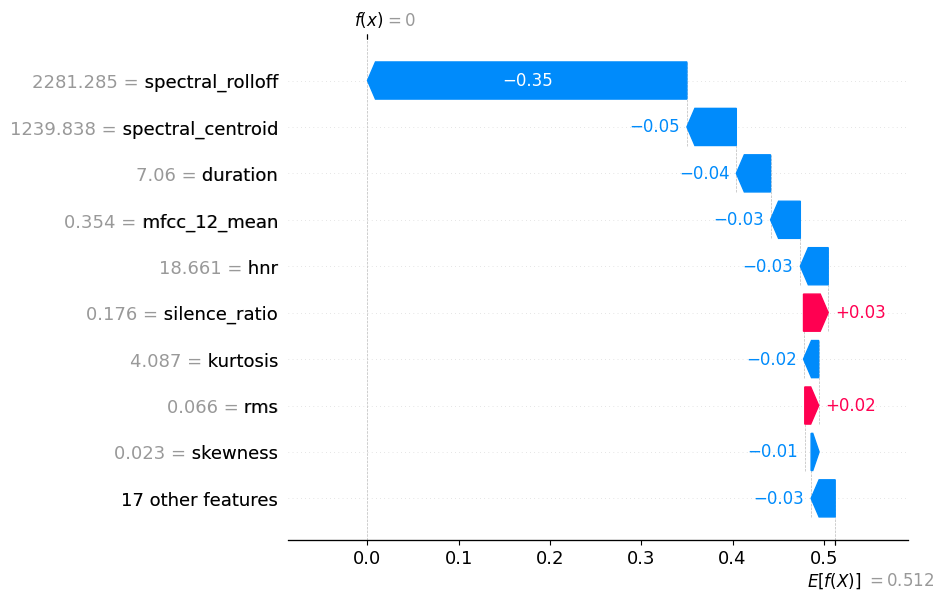

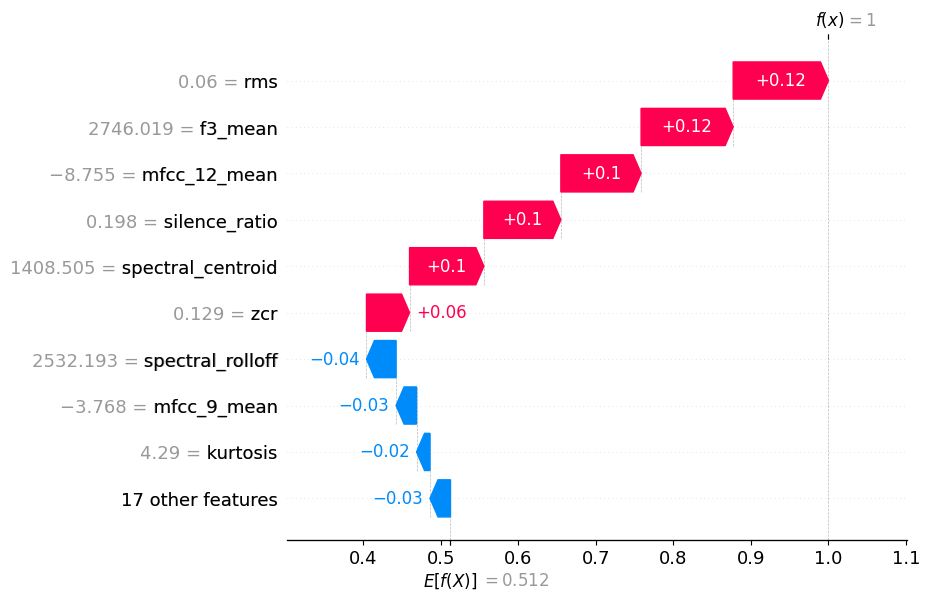

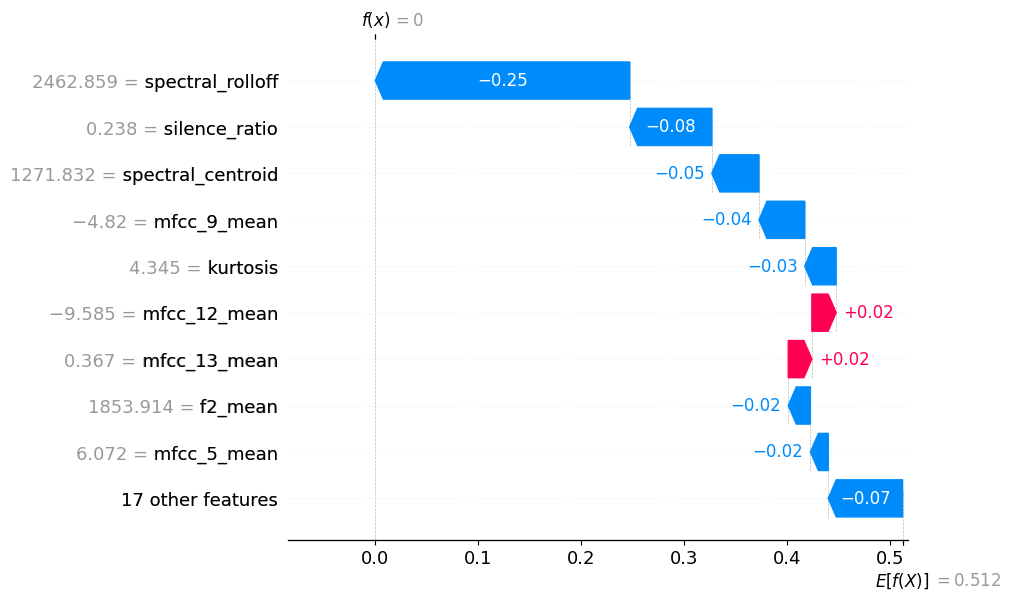

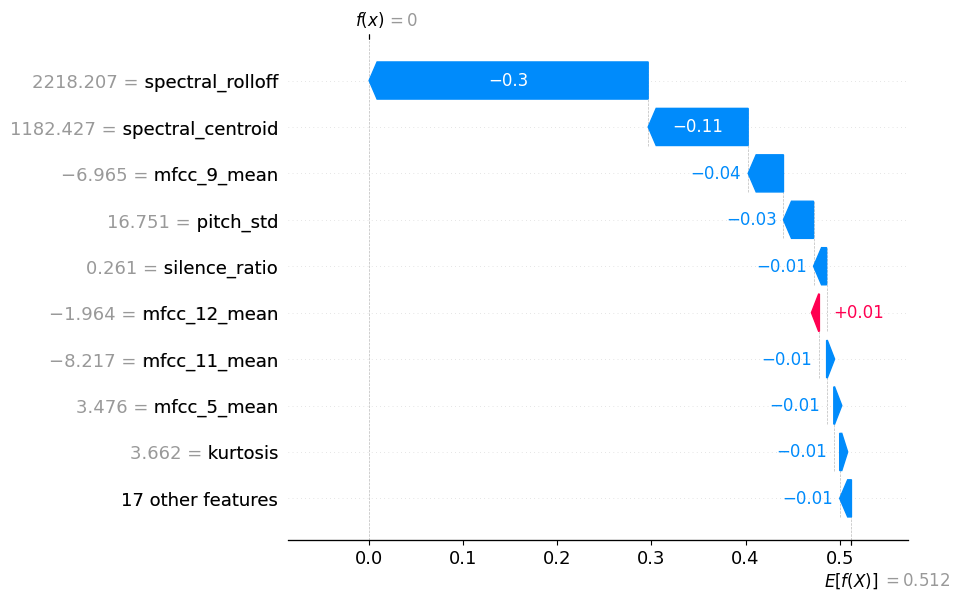

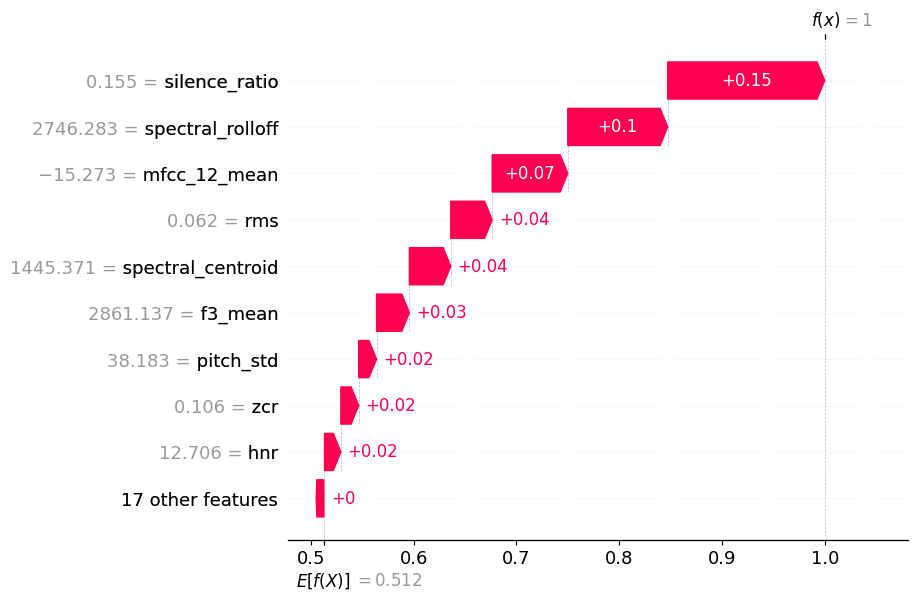

=== Evaluación Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.88      0.78      0.82         9

    accuracy                           0.85        20
   macro avg       0.85      0.84      0.85        20
weighted avg       0.85      0.85      0.85        20



In [ ]:
drop_features_explica_shap(X_train=X_train, X_test=X_test, feats=['spectral_flatness', 'mfcc_1_mean', 'spectral_bandwidth'], n_show=5, evalua_modelo=True)

# LIME

In [25]:
explainer = LimeTabularExplainer(X_train.values, feature_names=X.columns, class_names=['label'], mode='classification')
exp = explainer.explain_instance(X_test.values[0], rf_model.predict_proba)


# Obtenemos el HTML generado por LIME
exp_html = exp.as_html()


# Removemos las etiquetas <style> internas (que pueden estar forzando otros colores, para intentar quitar el formato por defecto)
exp_html_clean = re.sub(r'<style.*?>.*?</style>', '', exp_html, flags=re.DOTALL)

# Envolvemos el HTML limpio en un contenedor 
# también aplicamos un estilo global para forzar todo el contenido a tener fondo blanco
html_con_style = f"""
<style>
.lime-container * {{
    color: black !important;
    background-color: white !important;
    border-color: black !important;
}}
</style>
<div class="lime-container">
    {exp_html_clean}
</div>
"""

display(HTML(html_con_style))

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# DiCE

In [29]:
# Opción A: Si 'filename' NO es una feature relevante (elimínala)
X_train_clean = X_train.drop(columns=['filename'], errors='ignore')
X_test_clean = X_test.drop(columns=['filename'], errors='ignore')

# Combina features con target para DiCE
data_dice = X_train_clean.copy()
data_dice['label'] = y_train  # Asegúrate de que y_train es tu variable objetivo

In [32]:
data_dice.columns

Index(['duration', 'rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth',
       'spectral_rolloff', 'spectral_flatness', 'pitch_mean', 'pitch_std',
       'f1_mean', 'f2_mean', 'f3_mean', 'hnr', 'silence_ratio', 'mfcc_1_mean',
       'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean',
       'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean',
       'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean',
       'skewness', 'kurtosis', 'label'],
      dtype='object')

In [35]:
# Define el DataInterface
dice_data = dice_ml.Data(dataframe=data_dice, continuous_features=X_train_clean.columns.tolist(), outcome_name='label')
dice_model = dice_ml.Model(model=rf_model, backend='sklearn')
exp = dice_ml.Dice(dice_data, dice_model, method="random")

In [36]:
query = X_test_clean.iloc[[0]]  # Usa iloc en lugar de [0:1]
e1 = exp.generate_counterfactuals(query_instances=query, total_CFs=3, desired_class="opposite")
#e1 = exp.generate_counterfactuals(X_test[0:1], total_CFs=3, desired_class="opposite")
e1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.10it/s]

Query instance (original outcome : 0)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,7.059625,0.065675,0.096364,1239.837524,1221.232178,2281.2854,0.070297,187.984406,28.624744,644.17865,...,-4.921,-12.730546,-12.788556,-11.081859,-3.868264,0.354305,-1.823299,0.022784,4.08665,0



Diverse Counterfactual set (new outcome: 1)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-,-,0.148548192,-,-,-,0.0100785633,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,1522.78566,-,-,0.0352538282,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,0.0171464133,-,5.1696708,-,...,-,-,-,-,-,-,-,-,-,1.0
